In [1]:
#installing required libraries
!pip install pyspark==3.5.1 -qq #distributed data processing
!pip install pandas -qq #small local operations
!pip install matplotlib -qq #plotting graphs
!pip install scikit-learn -qq #machine learning
!pip install pyarrow -qq spark/panda interpretability

ERROR: Invalid requirement: '#distributed': Expected package name at the start of dependency specifier
    #distributed
    ^
ERROR: Invalid requirement: '#small': Expected package name at the start of dependency specifier
    #small
    ^
ERROR: Invalid requirement: '#plotting': Expected package name at the start of dependency specifier
    #plotting
    ^
ERROR: Invalid requirement: '#machine': Expected package name at the start of dependency specifier
    #machine
    ^
ERROR: Invalid requirement: 'spark/panda': Expected semicolon (after name with no version specifier) or end
    spark/panda
         ^


In [2]:
#key imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#spark session and SQL functions
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType

#Spark ML tools for feature engineering and recomedation
from pyspark.ml.feature import StringIndexer, Tokenizer, HashingTF, IDF
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.linalg import Vectors


In [3]:
#creating spark session

#environemnt variables that make spark use the same python interpreter as when the notebook is running.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

#build local spark session
spark = (
    SparkSession.builder
    .appName("SCC454-Amazon")
    .master("local[2]")#use 2 CPU threads locallu
    .config("spark.ui.port", "4050")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.python.worker.reuse", "true")
    .config("spark.driver.memory","4g")
    .config("spark.executor.memory","4g")

    .getOrCreate()
)

#reduce spark log noise
spark.sparkContext.setLogLevel("ERROR")
sc = spark.sparkContext



In [4]:
#Load data

# File paths
reviews_path = r"C:\Users\Egome\PycharmProjects\SCC454_Amazon\data\cleaned_reviews.jsonl"
metadata_path = r"C:\Users\Egome\PycharmProjects\SCC454_Amazon\data\cleaned_metadata.jsonl"

#read cleaned review data into spark df
reviews = spark.read.json(reviews_path)

#read cleaned product meta data into spark df
products = spark.read.json(metadata_path)

In [5]:
#check main recommender columns exists
reviews.select("user_id", "parent_asin", "rating").show(5)

# print schema for both data sets for visulisation
reviews.printSchema()
products.printSchema()

+--------------------+-----------+------+
|             user_id|parent_asin|rating|
+--------------------+-----------+------+
|AGKHLEW2SOWHNMFQI...| B00YQ6X8EO|   5.0|
|AGKHLEW2SOWHNMFQI...| B081TJ8YS3|   4.0|
|AE74DYR3QUGVPZJ3P...| B097R46CSY|   5.0|
|AFQLNQNQYFWQZPJQZ...| B09JS339BZ|   1.0|
|AFQLNQNQYFWQZPJQZ...| B08BZ63GMJ|   5.0|
+--------------------+-----------+------+
only showing top 5 rows

root
 |-- helpful_vote: long (nullable = true)
 |-- month: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- timestamp_convert: string (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- year: long (nullable = true)

root
 |-- Age Range (Description): string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Hair Type: string (nullable = true)
 |-- Item F

In [6]:
#build ratings dataframe

#fields required for recommendation
#user_id - users rating
#parent_asin - product rated
#rating - score

#cast the rating double type and drop the missing values
ratings = reviews.select(
    "user_id",
    "parent_asin",
    F.col("rating").cast("double").alias("rating")
).dropna(subset=["user_id", "parent_asin", "rating"])

# print schema to check rating table
ratings.printSchema()
ratings.show(5, truncate=False)

root
 |-- user_id: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)

+----------------------------+-----------+------+
|user_id                     |parent_asin|rating|
+----------------------------+-----------+------+
|AGKHLEW2SOWHNMFQIJGBECAF7INQ|B00YQ6X8EO |5.0   |
|AGKHLEW2SOWHNMFQIJGBECAF7INQ|B081TJ8YS3 |4.0   |
|AE74DYR3QUGVPZJ3P7RFWBGIX7XQ|B097R46CSY |5.0   |
|AFQLNQNQYFWQZPJQZS6V3NZU4QBQ|B09JS339BZ |1.0   |
|AFQLNQNQYFWQZPJQZS6V3NZU4QBQ|B08BZ63GMJ |5.0   |
+----------------------------+-----------+------+
only showing top 5 rows



In [7]:
# exploratory data analysis
#checking data sparsity
#because reccomender systems behave differently
#depending on the sparsity
# statistics
#total number of ratings
num_ratings = ratings.count()
#number of unique users
num_users = ratings.select("user_id").distinct().count()
#number of unique products
num_products = ratings.select("parent_asin").distinct().count()
#total number of products in metadata
total_products = products.select("parent_asin").distinct().count()

#sparsity of matrix
sparsity = 1 - (num_ratings / (num_users * total_products))

#printing stats
print(num_ratings, num_users, num_products, sparsity)

701528 631986 112565 0.9999901408895314


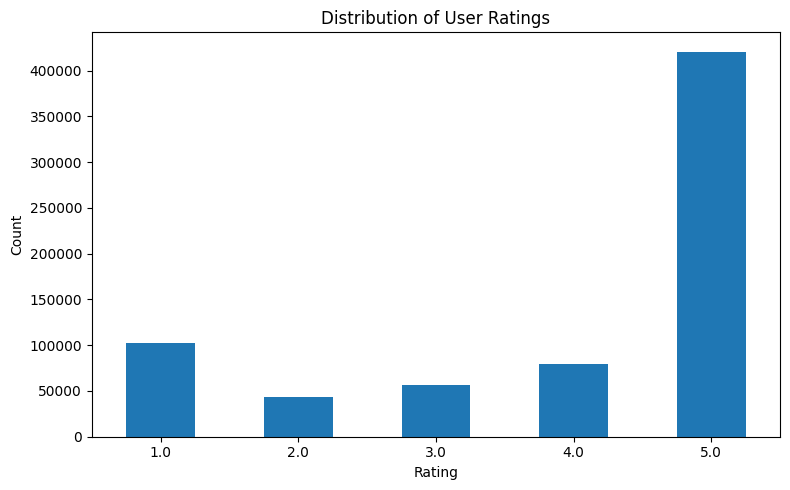

In [8]:
#ratings distribution
ratings_pd = ratings.select("rating").toPandas()

plt.figure(figsize=(8,5))
ratings_pd["rating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of User Ratings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

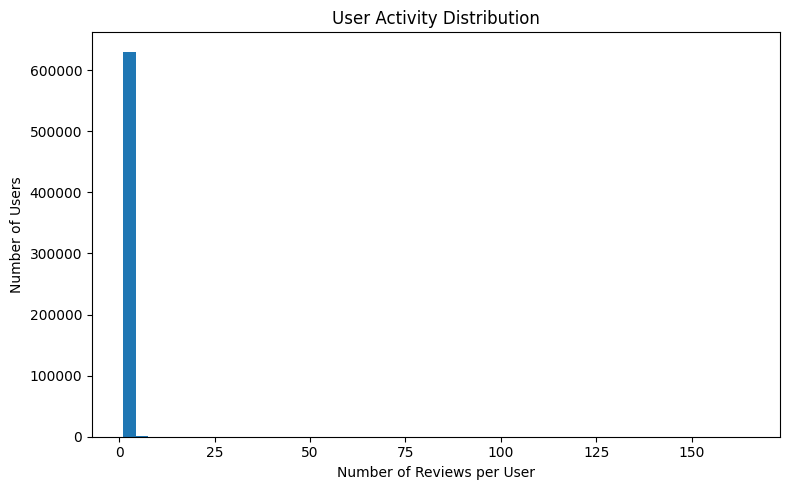

In [9]:
#user activity
user_activity = ratings.groupBy("user_id").count().toPandas()

plt.figure(figsize=(8,5))
plt.hist(user_activity["count"], bins=50)
plt.xlabel("Number of Reviews per User")
plt.ylabel("Number of Users")
plt.title("User Activity Distribution")
plt.tight_layout()
plt.show()

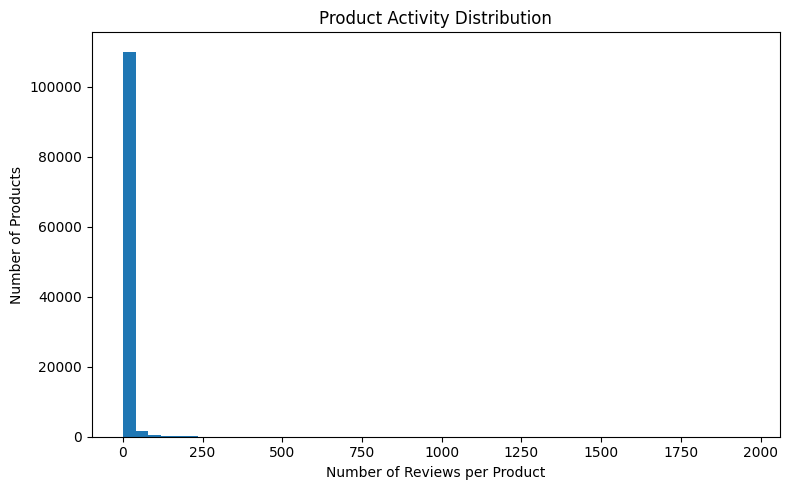

In [10]:
#product activity
item_activity = ratings.groupBy("parent_asin").count().toPandas()

plt.figure(figsize=(8,5))
plt.hist(item_activity["count"], bins=50)
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.title("Product Activity Distribution")
plt.tight_layout()
plt.show()

In [11]:
# Popularity baseline

#simple baseline recommender

#aggregate ratings by product
# Uses average rating and review count to rank products
#joins product meta data
#adds product title from roducts dataframe
#makes recommendations readable instead of ASIN ID's
popular_products = ratings.groupBy("parent_asin").agg(
    F.avg("rating").alias("avg_rating"),
    F.count("*").alias("review_count")
).join(
    products.select("parent_asin", "title"),
    on="parent_asin",
    how="left"
)

#create popularity score
#score combines rating quality and popularity
#log1p the review_count reduces the impact of extremely large review counts
popular_products = popular_products.withColumn(
    "popularity_score",
    F.col("avg_rating") * F.log1p(F.col("review_count"))
)

#sort products by highest popularity score and display the top 10 most popular products
popular_products.orderBy(F.desc("popularity_score")).show(10, truncate=False)

+-----------+------------------+------------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|parent_asin|avg_rating        |review_count|title                                                                                                                                                     |popularity_score  |
+-----------+------------------+------------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|B085BB7B1M |4.620285423037717 |1962        |salux nylon japanese beauty skin bath wash cloth towel 3 blue yellow pink                                                                                 |35.03206302044655 |
|B0C9CWKY9G |4.845620121422376 |1153        |picoway 20 pack mouse ear solid black red bow headband                     

C:\Users\Egome\AppData\Local\Temp\ipykernel_20860\3554400891.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


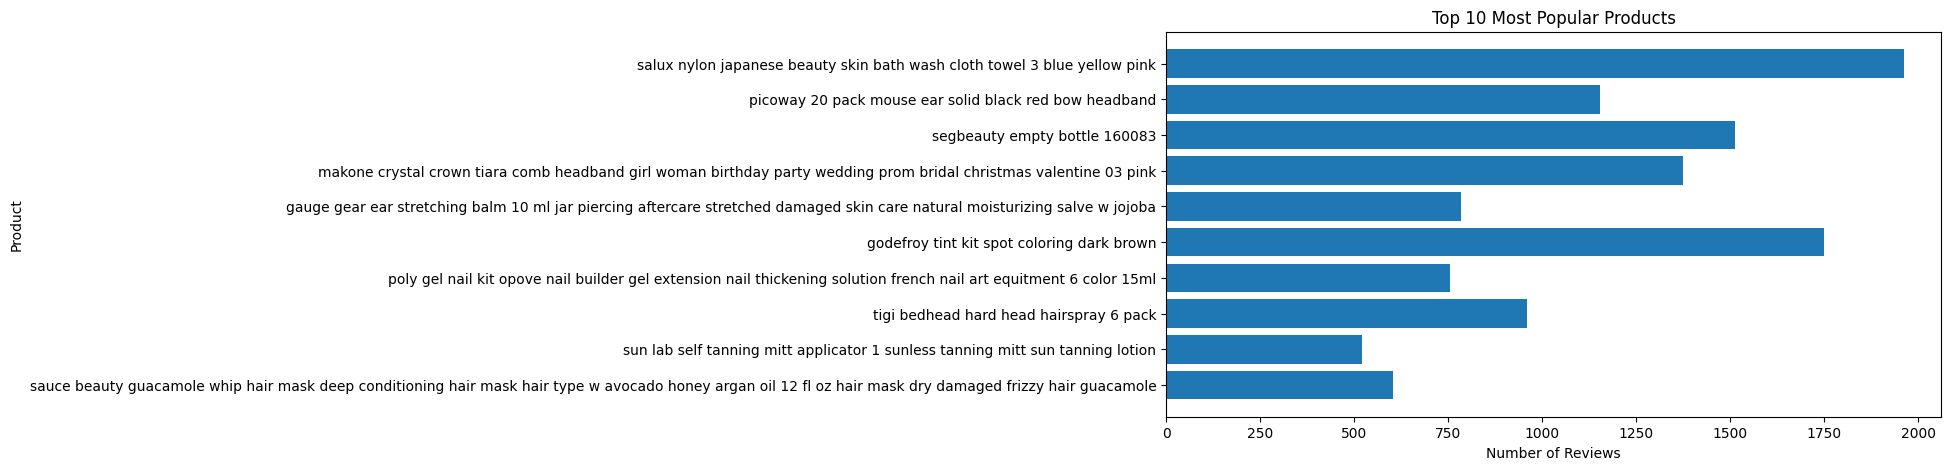

In [12]:
# graph - top 10 most popular products
top_popular_pd = popular_products.orderBy(F.desc("popularity_score")) \
    .select("title", "review_count", "popularity_score") \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(10,5))
plt.barh(top_popular_pd["title"], top_popular_pd["review_count"])
plt.xlabel("Number of Reviews")
plt.ylabel("Product")
plt.title("Top 10 Most Popular Products")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
def popularity_recommend(user_id, ratings_df, popularity_df, top_n=10):
    #recommends the most popular items that the user hasnt already rated
    #finds products the user has already seen/rated
    #removed those from the popularity table
    #return the top-n highest popularity score

    #products already rated by this user
    seen = ratings_df.filter(
        F.col("user_id") == user_id
    ).select("parent_asin").distinct()

    #keep only unseen products and sort by popularity
    recs = popularity_df.join(
        seen, "parent_asin", "left_anti"
    ).orderBy(
        F.desc("popularity_score")
    ).select(
        "parent_asin", "title", "popularity_score"
    ).limit(top_n)

    #prints popularity recommendations for user
    print(f"\nTop {top_n} Popularity Recommendations for User {user_id}:")
    recs.show(truncate=False)

    return recs

In [14]:
def evaluate_popularity_precision_at_k(ratings_df, popularity_df, k=10, relevance_threshold=4.0, sample_n_users=10):
    total_precision = 0.0
    valid_users = 0

    sampled_users = [
        row["user_id"]
        for row in ratings_df.select("user_id").distinct().limit(sample_n_users).collect()
    ]

    for user_id in sampled_users:
        seen = ratings_df.filter(
            F.col("user_id") == user_id
        ).select("parent_asin").distinct()

        recs_df = popularity_df.join(
            seen, "parent_asin", "left_anti"
        ).orderBy(
            F.desc("popularity_score")
        ).select("parent_asin").limit(k)

        recommended_asins = {row["parent_asin"] for row in recs_df.collect()}

        relevant_asins = {
            row["parent_asin"]
            for row in ratings_df.filter(
                (F.col("user_id") == user_id) & (F.col("rating") >= relevance_threshold)
            ).select("parent_asin").distinct().collect()
        }

        if len(relevant_asins) == 0:
            continue

        hits = len(recommended_asins.intersection(relevant_asins))
        total_precision += hits / k
        valid_users += 1

    avg_precision = total_precision / valid_users if valid_users > 0 else 0.0
    print(f"\nPopularity Precision@{k}: {avg_precision:.4f}")
    return avg_precision

In [15]:
# Test popularity baseline on one sample user
sample_user = ratings.select("user_id").distinct().limit(1).collect()[0]["user_id"]
popularity_recommend(sample_user, ratings, popular_products, top_n=10)


Top 10 Popularity Recommendations for User AGKHLEW2SOWHNMFQIJGBECAF7INQ:
+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|parent_asin|title                                                                                                                                                     |popularity_score  |
+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|B085BB7B1M |salux nylon japanese beauty skin bath wash cloth towel 3 blue yellow pink                                                                                 |35.03206302044655 |
|B0C9CWKY9G |picoway 20 pack mouse ear solid black red bow headband                                                                                                    |34.166

DataFrame[parent_asin: string, title: string, popularity_score: double]

content based filtering
recomending items similar to what user has previously liked
-build item profiles - feature vector using TF-IDF
-build user profiles - aggregate profiles of items user rated high
-predict- compute similarity - distance between user profile and candidate items - using cosine
-recommend items where the vectors are most similar to the user profile

In [16]:
# merge title and description into a single text field per product
product_content = products.withColumn(
    "content_text",
    F.concat_ws(
        " ",
        F.coalesce(F.col("title"), F.lit("")),
        F.coalesce(F.col("description"), F.lit(""))
    )
)

product_content.select("parent_asin", "title", "content_text").show(5, truncate=80)

# tokenise the text into list of words
tokenizer = Tokenizer(inputCol="content_text", outputCol="words")
product_words = tokenizer.transform(product_content)

# convert token lists into hash frequency vectors using hashing (HashingTF)
# numFeatures controls the dimensionality of hash space — larger = fewer collisions
hashingTF = HashingTF(inputCol="words", outputCol="raw_features", numFeatures=256)
product_tf = hashingTF.transform(product_words)

# apply IDF weighting so common words have less importance
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idf_model = idf.fit(product_tf)
product_tfidf = idf_model.transform(product_tf)

# cache the result
product_tfidf = product_tfidf.select(
    "parent_asin",
    "title",
    "content_text",
    "tfidf_features"
).cache()

#print to check vectors
product_tfidf.show(3, truncate=60)

+-----------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|parent_asin|                                                                           title|                                                                    content_text|
+-----------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
| B01CUPMQZE|                                 howard lc008 leather conditioner 8 ounce 4 pack|                                howard lc008 leather conditioner 8 ounce 4 pack |
| B076WQZGPM|yes tomato detoxifying charcoal cleanser pack 2 charcoal powder tomato fruit ...|yes tomato detoxifying charcoal cleanser pack 2 charcoal powder tomato fruit ...|
| B000B658RI|                                       eye patch black adult tie band 6 per pack|                          

In [17]:
# Test: inspect some product titles
product_tfidf.select("title").show(20, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|title                                                                                                                                                                                   |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|howard lc008 leather conditioner 8 ounce 4 pack                                                                                                                                         |
|yes tomato detoxifying charcoal cleanser pack 2 charcoal powder tomato fruit extract gingko biloba leaf extract 5 fl oz                                                                 |
|eye patch black adult tie band 6 per pack                       

compute item-item similarity between tf-idf vectors using cosine
equation - cos(x,i)=x⋅i/∥x∥⋅∥i∥

In [18]:
def cosine_similarity(v1, v2):
    #compute cosine similarity between two spark ML vectors

    #convert spark vecotrs to NumPy arrays
    a1 = v1.toArray()
    a2 = v2.toArray()

    #dot product measures the alignment
    dot = float(np.dot(a1, a2))
    norm1 = float(np.linalg.norm(a1))
    norm2 = float(np.linalg.norm(a2))

    #avoid division by zero for empty vectors
    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot / (norm1 * norm2)


def find_similar_products(product_title, product_tfidf_df, top_n=10):
    #find the top-N most similar products to a given product title
    #using cosine similarity on TF-IDF vectors.

    #find one target product where the title contains the search phrase
    target = product_tfidf_df.filter(
        F.col("title").contains(product_title)
    ).first()

    if target is None:
        print(f"Product '{product_title}' not found!")
        return None

    target_vec = target["tfidf_features"]
    target_id = target["parent_asin"]

    print(f"Finding products similar to: {target['title']}")
    print("=" * 70)

    #collect all the other products locally
    #this code is expensive so takes ages to run
    all_products = product_tfidf_df.filter(
        F.col("parent_asin") != target_id
    ).collect()

    similarities = []
    for row in all_products:
        sim = cosine_similarity(target_vec, row["tfidf_features"])
        similarities.append((row["parent_asin"], row["title"], sim))

    #rank by highest similarity
    similarities.sort(key=lambda x: x[2], reverse=True)

    for i, (asin, title, sim) in enumerate(similarities[:top_n], 1):
        print(f"{i:2d}. {title[:60]:60s} | ASIN={asin} | sim={sim:.4f}")

    return similarities[:top_n]

Building user profiles
user profile is a weighted average of item profiles for products the user has rated highly
for each item - the tf-idf vector is weighted by the users rating then normalised

In [19]:
def build_user_profile(user_id, ratings_df, product_tfidf_df, min_rating=3.5):
    #build a user profile from products the user liked

    # take products the user rated at/above the minimum rating
    # get their TF-IDF vectors
    #compute weighted average using the rating as the weight

    #returns (user_profile_vector, list_of_rated_product_ids)
    #dense user profile and list of product IDs that the user already rated highly

    #keeps the users positive rated products only
    user_ratings = ratings_df.filter(
        (F.col("user_id") == user_id) & (F.col("rating") >= min_rating)
    )
    #attatch TF-IDF vectors for those products
    user_products = user_ratings.join(product_tfidf_df, "parent_asin")

    #collect product ID's already used in the profile
    rated_products = user_products.select("parent_asin").rdd.flatMap(lambda x: x).collect()

    #collect ratings and vectors locally to compute weighted average
    user_data = user_products.select("rating", "tfidf_features").collect()

    if len(user_data) == 0:
        print(f"User {user_id} has no ratings above {min_rating}")
        return None, []

    #initialise empty vector of the same size as TF-IDF vector
    vec_size = len(user_data[0]["tfidf_features"])
    weighted_sum = np.zeros(vec_size)
    total_weight = 0.0

    #add rating-weighted vectors
    for row in user_data:
        weight = row["rating"]
        weighted_sum += weight * row["tfidf_features"].toArray()
        total_weight += weight

    #average the weighted vectors
    profile = weighted_sum / total_weight

    print(f"User {user_id}: profile built from {len(user_data)} highly-rated products")
    return Vectors.dense(profile), rated_products


In [20]:
def content_based_recommend(user_id, ratings_df, product_tfidf_df, products_df, top_n=10, verbose=True):
    #generate content-based recommendations for a user

    user_profile, rated_ids = build_user_profile(
        user_id, ratings_df, product_tfidf_df
    )

    if user_profile is None:
        return None

    candidate_products = product_tfidf_df.filter(
        ~F.col("parent_asin").isin(rated_ids)
    ).collect()

    scores = []
    for row in candidate_products:
        sim = cosine_similarity(user_profile, row["tfidf_features"])
        scores.append((row["parent_asin"], row["title"], sim))

    scores.sort(key=lambda x: x[2], reverse=True)

    if verbose:
        print(f"\nTop {top_n} Content-Based Recommendations for User {user_id}:")
        print("=" * 80)
        for i, (asin, title, score) in enumerate(scores[:top_n], 1):
            print(f"{i:2d}. {title[:60]:60s} | ASIN={asin} | score={score:.4f}")

        print(f"\nBased on the user's highly-rated products:")
        user_liked = ratings_df.filter(
            (F.col("user_id") == user_id) & (F.col("rating") >= 4.0)
        ).join(products_df, "parent_asin") \
         .select("title", "rating") \
         .orderBy(F.desc("rating"))

        user_liked.show(10, truncate=False)

    return scores[:top_n]

In [21]:
def evaluate_content_precision_at_k(user_ids, ratings_df, product_tfidf_df, products_df, k=10, relevance_threshold=4.0):
    total_precision = 0.0
    valid_users = 0

    relevant_items_df = ratings_df.filter(
        (F.col("user_id").isin(user_ids)) & (F.col("rating") >= relevance_threshold)
    ).select("user_id", "parent_asin").distinct()

    for user_id in user_ids:
        recs = content_based_recommend(
            user_id,
            ratings_df,
            product_tfidf_df,
            products_df,
            top_n=k,
            verbose=False
        )

        if recs is None:
            continue

        recommended_asins = {asin for asin, title, score in recs}

        user_relevant = {
            row["parent_asin"]
            for row in relevant_items_df.filter(F.col("user_id") == user_id).collect()
        }

        if len(user_relevant) == 0:
            continue

        hits = len(recommended_asins.intersection(user_relevant))
        total_precision += hits / k
        valid_users += 1

    avg_precision = total_precision / valid_users if valid_users > 0 else 0.0
    print(f"\nContent-Based Precision@{k}: {avg_precision:.4f}")
    return avg_precision

In [22]:
#run content-based recommendations for one user
recs = content_based_recommend(sample_user, ratings, product_tfidf, products)

User AGKHLEW2SOWHNMFQIJGBECAF7INQ: profile built from 2 highly-rated products

Top 10 Content-Based Recommendations for User AGKHLEW2SOWHNMFQIJGBECAF7INQ:
 1. herbivore natural sea mist texturizing salt spray coconut tr | ASIN=B015RR870U | score=0.4718
 2. moyo natural lab 8 oz spray bottle trigger sprayer empty tra | ASIN=B01DZ02WZW | score=0.4595
 3. moyo natural lab 8 oz pride pack spray bottle trigger spraye | ASIN=B06Y1XCZ9S | score=0.4568
 4. travel dry shampoo powder eco friendly natural root touch ve | ASIN=B081QVZ8CV | score=0.4539
 5. travel dry shampoo powder eco friendly natural root touch ve | ASIN=B081TH5HJJ | score=0.4490
 6. shampoo dry hair flaking scalp moisturizing anti frizz nouri | ASIN=B01I7OCNSM | score=0.4443
 7. wild natural baby bubble natural baby shampoo sulfate free p | ASIN=B002A8C4E0 | score=0.4408
 8. u part wig human hair straight wig human hair 150 density gl | ASIN=B08XTK4GN6 | score=0.4318
 9. 16 inch u part wig human hair straight brazilian virgin h

In [23]:
#find products similar to a keyword/title
similar = find_similar_products("lipstick", product_tfidf, top_n=10)

Finding products similar to: 3d mask bracket kid internal support holder frame nose breathing smoothly protect lipstick lip cool face mask inner support frame 5pcs
 1. 3d mask bracket internal support holder frame nose breathing | ASIN=B08FBHNBP1 | sim=0.9761
 2. 3d mask bracket cherislpy protect lipstick lip internal supp | ASIN=B08GPH58GP | sim=0.6960
 3. 3d mask bracket inner support frame frame lipstick protector | ASIN=B08H8LQ3ZP | sim=0.6954
 4. mask bracket 10pcs silicone face mask bracket set comfortabl | ASIN=B08QVH2W5K | sim=0.6945
 5. qlv mask bracket 10pcs silicone face mask bracket set comfor | ASIN=B08QTSQJGT | sim=0.6938
 6. 3d mask bracket stywvoe protect lipstick lip internal suppor | ASIN=B08H52N5Z4 | sim=0.6893
 7. 3d mask bracket 5pcs mask stand mask accessory inner support | ASIN=B08DR9Q1Q1 | sim=0.6791
 8. 3d face mask silicone insert mask frame support homemade clo | ASIN=B08PL279YL | sim=0.6746
 9. 3d mask bracket rondan silicone inner support frame space co | A

collaborative filtering with ALS


works directly on the utility matrix without item features
-user-user CF -users with similar rating patterns -predicted from the ratings
-item-item CF - items with similar rated similarity predicted from similar items

Alternating least squares (ALS) is matrix factorisation
it decomposes the user-item rating matrix into low-dimensional latent factor matrices for users and items.

matrix R ~~UxV^T
U = users factors, V= item factors where latent preferences are represented
spark MLlib has ALS alternating least squares - standard distributed algorithm for matrix factorisation

intuition
-users with similar rating behaviour get similar latent vectors
-items liked by simailar kinds of users get similar letent vector
-this allows prediction of missing ratings


In [24]:
#preparing data for ALS


# convert string IDs to numeric indices for ALS
user_indexer = StringIndexer(inputCol="user_id", outputCol="user_idx")
item_indexer = StringIndexer(inputCol="parent_asin", outputCol="item_idx")

#fix indexers and transform data
ratings_indexed = user_indexer.fit(ratings).transform(ratings)
ratings_indexed = item_indexer.fit(ratings_indexed).transform(ratings_indexed)

# select numeric columns required for ALS
ratings_als = ratings_indexed.select(
    F.col("user_idx").cast("int"),
    F.col("item_idx").cast("int"),
    F.col("rating").cast("float")
)

ratings_als.show(5, truncate=False)
ratings_als.printSchema()

# Train/test split 80/20
#training used to fit model, test used to evaluate
(training, test) = ratings_als.randomSplit([0.8, 0.2], seed=42)

# cache to reuse dataframes quicker
training.cache()
test.cache()

training.limit(5).show()
test.limit(5).show()

+--------+--------+------+
|user_idx|item_idx|rating|
+--------+--------+------+
|33934   |722     |5.0   |
|33934   |9669    |4.0   |
|71462   |4203    |5.0   |
|26005   |109899  |1.0   |
|26005   |42259   |5.0   |
+--------+--------+------+
only showing top 5 rows

root
 |-- user_idx: integer (nullable = true)
 |-- item_idx: integer (nullable = true)
 |-- rating: float (nullable = true)

+--------+--------+------+
|user_idx|item_idx|rating|
+--------+--------+------+
|       0|      48|   5.0|
|       0|     115|   5.0|
|       0|     589|   5.0|
|       0|     645|   5.0|
|       0|     652|   4.0|
+--------+--------+------+

+--------+--------+------+
|user_idx|item_idx|rating|
+--------+--------+------+
|       0|     230|   4.0|
|       0|     653|   5.0|
|       0|     788|   5.0|
|       0|    1551|   3.0|
|       0|    2881|   4.0|
+--------+--------+------+



In [25]:
print(f"Training ratings: {training.count():,}")
print(f"Test ratings:     {test.count():,}")

Training ratings: 561,100
Test ratings:     140,428


Training ALS model
key hyperparameters
-rank - number of latent factors
-maxInter - number of optimisation iterations
-redParam - regularisation strength
- coldstartstrategy - 'drop' - drop unknown user/item predictions in evaluation

Parameter	Description
rank	Number of latent factors (dimensionality of U, V)
maxIter	Number of ALS iterations
regParam	Regularisation parameter (prevents overfitting)
coldStartStrategy	How to handle unknown users/items at prediction time

In [26]:
# Build ALS model
als = ALS(
    rank=20,
    maxIter=5,
    regParam=0.1,
    userCol="user_idx",
    itemCol="item_idx",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=False,
    seed=42
)

print("Training ALS model...")

model = als.fit(training)

print("Training complete!")

Training ALS model...
Training complete!


evaluating the model with RMSE

RMSE is the standard metric:

RMSE=√1N∑(x,i)∈R(rhatxi−rxi)^2

In [27]:
#root mean squared error(RMSE)
#lower RMSE means the predicted ratings are, on average
#becuase it's closer to the true ratings
# Generate predictions on test set
predictions = model.transform(test)

# show some predictions vs actual ratings
#joins prediction results with product names to inspect outputs more easily
predictions_with_names = predictions.join(
    ratings_indexed.select("item_idx", "parent_asin").dropDuplicates(),
    on="item_idx",
    how="left"
).join(
    products.select("parent_asin", "title"),
    on="parent_asin",
    how="left"
)

predictions_with_names.select(
    "user_idx",
    "title",
    "rating",
    "prediction"
).show(15, truncate=40)

# Compute RMSE on the test set
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(predictions)

print(f"\nTest RMSE: {rmse:.4f}")

+--------+----------------------------------------+------+----------+
|user_idx|                                   title|rating|prediction|
+--------+----------------------------------------+------+----------+
|    2317|meeteasy dental cleaner tool kit dent...|   5.0|  4.219764|
|    6612|meeteasy dental cleaner tool kit dent...|   5.0|-0.4879859|
|   17514|meeteasy dental cleaner tool kit dent...|   4.0| 0.1511695|
|   18163|meeteasy dental cleaner tool kit dent...|   5.0|0.35536265|
|   34582|meeteasy dental cleaner tool kit dent...|   5.0| 0.8754189|
|    4684|meeteasy dental cleaner tool kit dent...|   5.0|  4.695973|
|    5727|meeteasy dental cleaner tool kit dent...|   5.0|  4.695973|
|   12602|meeteasy dental cleaner tool kit dent...|   5.0|0.46096167|
|   19929|meeteasy dental cleaner tool kit dent...|   5.0|  4.695973|
|   22759|meeteasy dental cleaner tool kit dent...|   1.0| 0.5741509|
|   31176|meeteasy dental cleaner tool kit dent...|   2.0|0.07842428|
|    2649|meeteasy d

generating reccomendations

In [28]:
# generate als recommendations for one sample user
#chose one sample user from the indexed user ID's
sample_user_idx = ratings_indexed.select("user_idx").distinct().limit(1)
user_recs = model.recommendForUserSubset(sample_user_idx, 10)

print("Schema of recommendations:")
user_recs.printSchema()

user_recs.show(1, truncate=False)

Schema of recommendations:
root
 |-- user_idx: integer (nullable = false)
 |-- recommendations: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- item_idx: integer (nullable = true)
 |    |    |-- rating: float (nullable = true)

+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_idx|recommendations                                                                                                                                                                                   |
+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|33934   |[{111971, 6.201994}, {10387, 6.097551}, {8215, 6.0464892}, {55726, 6.0051847}, {7889, 5.756919}, {23783, 

latent factors understanding
ALS learns latent factor vectors for each user and each item - this looks at what the model has learned

In [29]:
#inspect als item factors by finding similar products
def find_similar_products_als(product_title, model, ratings_indexed_df, products_df, top_n=5):
    #finds similar products using ALS item latent factors instead of text
    #products are similar if they occupy nearby positions in the latent factor space learned from user ratings

    # finds the target product by metadata title
    target = products_df.filter(
        F.lower(F.col("title")).contains(product_title.lower())
    ).select("parent_asin", "title").first()

    if not target:
        print(f"Product '{product_title}' not found!")
        return

    # get the target's internal ALS ID (item_idx) for that product
    target_idx_row = ratings_indexed_df.filter(
        F.col("parent_asin") == target["parent_asin"]
    ).select("item_idx").first()

    if not target_idx_row:
        print("Product ID mapping not found.")
        return

    target_id = int(target_idx_row["item_idx"])

    # get the learned latent factor vector for that product
    # target vector and broadcast it
    target_factor = model.itemFactors.filter(F.col("id") == target_id).select("features").first()
    if not target_factor:
        return

    # broadcast the target vector to all workers for efficient distributed similarity calculation
    broadcast_vec = sc.broadcast(np.array(target_factor["features"]))

    #define cosine similarity between the target vector and another item's factors
    def spark_cosine_sim(features):
        v1 = broadcast_vec.value
        v2 = np.array(features)
        dot = np.dot(v1, v2)
        norm = np.linalg.norm(v1) * np.linalg.norm(v2)
        return float(dot / norm) if norm > 0 else 0.0

    cosine_udf = F.udf(spark_cosine_sim, FloatType())

    #calculate similarity against all item factors in spark
    similar_items_df = model.itemFactors \
        .filter(F.col("id") != target_id) \
        .withColumn("sim", cosine_udf(F.col("features"))) \
        .orderBy(F.col("sim").desc()) \
        .limit(top_n)

    #map item index back to title/parent_asin for readable output
    results = similar_items_df.join(
        ratings_indexed_df.select("item_idx", "parent_asin").dropDuplicates(),
        similar_items_df.id == ratings_indexed_df.item_idx
    ).join(
        products_df.select("parent_asin", "title"),
        on="parent_asin",
        how="left"
    ).select("title", "parent_asin", "sim").orderBy(F.col("sim").desc()).collect()

    # print results
    print(f"Products similar to: {target['title']}")
    print("-" * 80)
    for i, row in enumerate(results):
        print(f"{i+1}. {str(row['title'])[:50]:50} | Sim: {row['sim']:.4f}")



In [30]:
#displays the first 20 product titles from the products  dataframe without shortening the text, inspects the product names
products.select("title").show(20, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|title                                                                                                                                                                                   |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|howard lc008 leather conditioner 8 ounce 4 pack                                                                                                                                         |
|yes tomato detoxifying charcoal cleanser pack 2 charcoal powder tomato fruit extract gingko biloba leaf extract 5 fl oz                                                                 |
|eye patch black adult tie band 6 per pack                       

In [31]:
#selects a sample user from the dataset and generated up to 10 product recommendations using the tarined ASL model and then displays the recommendation structure and results
sample_users = ratings_indexed.select("user_idx").distinct().limit(1)
user_recs = model.recommendForUserSubset(sample_users, 10)
user_recs.printSchema()
user_recs.show(5,truncate=False)

root
 |-- user_idx: integer (nullable = false)
 |-- recommendations: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- item_idx: integer (nullable = true)
 |    |    |-- rating: float (nullable = true)

+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_idx|recommendations                                                                                                                                                                                   |
+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|33934   |[{111971, 6.201994}, {10387, 6.097551}, {8215, 6.0464892}, {55726, 6.0051847}, {7889, 5.756919}, {23783, 5.6561933}, {24844, 5.62029

In [32]:
#runds ALS similarity function to find the top 5 products most similar to selected product (e.g. foundation) based on learned item latent factors from user rating patterns
find_similar_products_als("foundation", model, ratings_indexed, products, top_n=5)

Products similar to: loose powder 1 5oz bottle loose face powder translucent tone loose face powder setting makeup foundation lightweight long lasting
--------------------------------------------------------------------------------
1. m c lustreglass lipstick sheer shine 548 beam done | Sim: 0.8125
2. make cut gel couture nail polish                   | Sim: 0.8014
3. moisturizing green tea sleeping lip mask balm best | Sim: 0.7990
4. imprint cumulus pro comfort mat black 24x36        | Sim: 0.7806
5. rainbow luxury bath spa foam waterproof pillow bla | Sim: 0.7749


Compare the "similar products" results from content-based and collaborative filtering:

Content-based finds products with similar genres/tags (e.g., other lipstick products b and c )
Content-based filtering finds products with similar text features, such as title and description.
ALS finds products that the same users tended to rate similarly, even if the items are not textually similar.
For example, ALS might recommend a lip product alongside a skincare item if users who liked one often also liked the other.

hyperparameter tuning
The rank (number of latent factors) and regParam significantly affect model quality. this systematically evaluates different settings

In [33]:
# grid search over rank and regularisation
#tests multiple values of rank and regparam to see which gives the best RMSE on the test set
results = []

ranks = [5, 10, 20, 50]
reg_params = [0.001, 0.01, 0.1, 0.5, 0.75, 1]

print(f"{'Rank':>6} {'RegParam':>10} {'RMSE':>10}")
print("-" * 30)

# reuse cached trained/test splits
training_tune = training.cache()
test_tune = test.cache()

for rank in ranks:
    for reg in reg_params:
        #create a temp ALS model with the current hyperparameter

        als_temp = ALS(
            rank=rank,
            maxIter=5,
            regParam=reg,
            userCol="user_idx",
            itemCol="item_idx",
            ratingCol="rating",
            coldStartStrategy="drop",
            seed=42
        )

        #fit and evaluate
        model_temp = als_temp.fit(training_tune)

        preds_temp = model_temp.transform(test_tune)

        rmse_temp = evaluator.evaluate(preds_temp)

        results.append((rank, reg, rmse_temp))

        print(f"{rank:>6} {reg:>10.2f} {rmse_temp:>10.4f}")

#best is lowest RMSE
best = min(results, key=lambda x: x[2])

print(f"\nBest: rank={best[0]}, regParam={best[1]}, RMSE={best[2]:.4f}")

  Rank   RegParam       RMSE
------------------------------
     5       0.00    10.3631
     5       0.01     6.4146
     5       0.10     4.6092
     5       0.50     4.1506
     5       0.75     4.1179
     5       1.00     4.1011
    10       0.00     5.9338
    10       0.01     4.7530
    10       0.10     4.2129
    10       0.50     3.9779
    10       0.75     3.9693
    10       1.00     3.9720
    20       0.00     4.6192
    20       0.01     4.2560
    20       0.10     4.0347
    20       0.50     3.8879
    20       0.75     3.8934
    20       1.00     3.9085
    50       0.00     4.2063
    50       0.01     4.0304
    50       0.10     3.9237
    50       0.50     3.8373
    50       0.75     3.8505
    50       1.00     3.8719

Best: rank=50, regParam=0.5, RMSE=3.8373


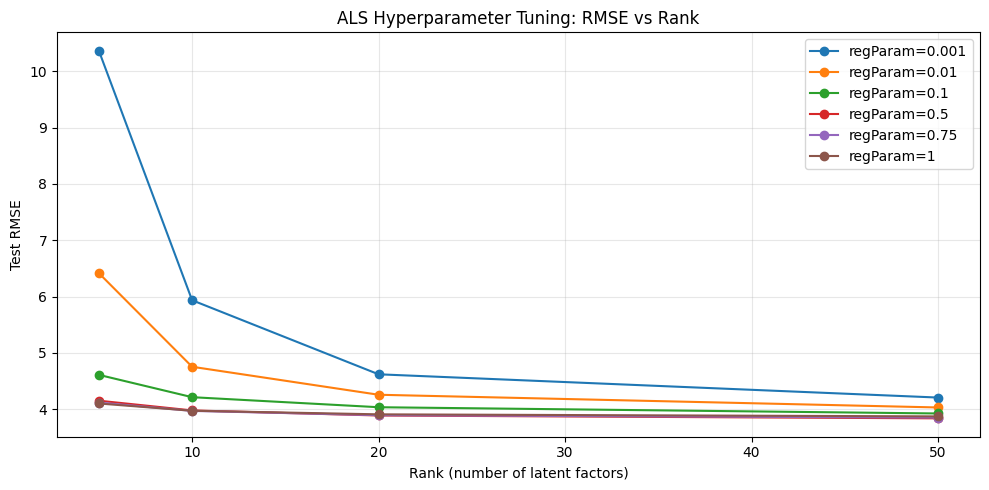

In [34]:
# visualise tuning results
results_df = pd.DataFrame(results, columns=["rank", "regParam", "RMSE"])

fig, ax = plt.subplots(figsize=(10, 5))

#plot one line per regraparm
for reg in reg_params:
    subset = results_df[results_df["regParam"] == reg]
    ax.plot(subset["rank"], subset["RMSE"], marker="o", label=f"regParam={reg}")

ax.set_xlabel("Rank (number of latent factors)")
ax.set_ylabel("Test RMSE")
ax.set_title("ALS Hyperparameter Tuning: RMSE vs Rank")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

evaluation and comparison
ranking metrics additional to RMSE

RMSE has limitations:
It treats all errors equally- but we mainly care about predicting high ratings correctly
It doesn't capture whether the top recommendations are relevant


useing Precision@K — the fraction of recommended items that are relevant.

RMSE measures rating prediction accuracy but the reccomendation quality is also about if the items are relevent so use the precision accuracy to see if recomended items are relevent

In [35]:
#ranking evaluation
# precision@K
#the proportion of the top-K recommended items that are relevant

def evaluate_precision_at_k(model, test_df, k=10, relevance_threshold=4.0):
    #evaluate_preciison@K for an ALS model
    #relevant items are ones with rating >= relevance_threshold in the test set

    #keep only relevant test interactions
    relevant_test = test_df.filter(F.col("rating") >= relevance_threshold)
    test_users = relevant_test.select("user_idx").distinct()

    #recommend only for users in the test set
    # subset faster than recommendForAllUsers
    user_recs = model.recommendForUserSubset(test_users, k)

    # flatten the nested recommendation structure
    recs_flat = user_recs.select(
        F.col("user_idx"),
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("user_idx"),
        F.col("rec.item_idx").alias("item_idx")
    )

    #match recommended items against relevant items
    # use an inner join to check relevance
    precision_df = recs_flat.join(
        relevant_test,
        ["user_idx", "item_idx"],
        "inner"
    ).groupBy("user_idx").agg(
        (F.count("item_idx") / F.lit(k)).alias("user_p")
    )

    #include users with zero hits
    # handles users who got 0 relevant recs - dont include in the inner join
    # joins back to the test_users to ensure the average includes the zeros
    final_avg = precision_df.join(test_users, "user_idx", "right") \
        .fillna(0, subset=["user_p"]) \
        .agg(F.avg("user_p")).first()[0]

    return final_avg

In [36]:
# evaluates asl models recommendation acuracy by calculating  precision at different K values k(5,10,20,50)
print(f"{'K':>5} {'Precision@K':>15}")
print("-" * 25)

precisions = []

for k in [5, 10, 20, 50]:
    p = evaluate_precision_at_k(model, test, k=k)
    precisions.append((k, p))
    print(f"{k:>5} {p:>15.6f}")

    K     Precision@K
-------------------------
    5        0.002162
   10        0.001140
   20        0.000592
   50        0.000256


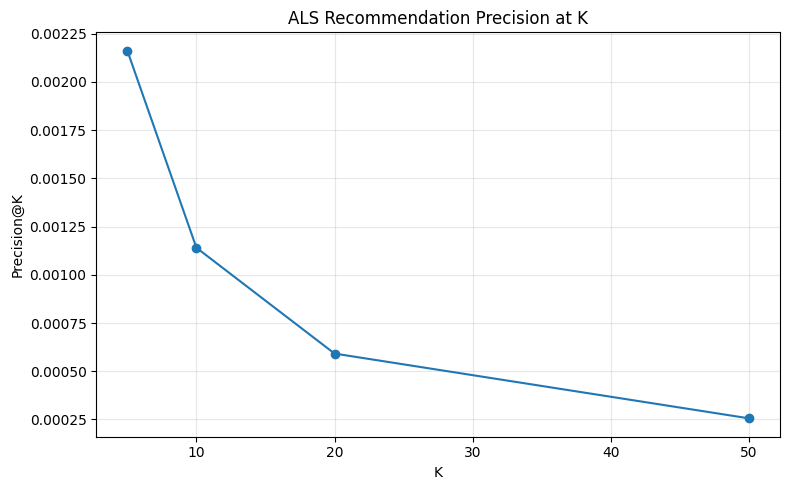

In [37]:
# graph - precision@k
precision_pd = pd.DataFrame(precisions, columns=["K", "Precision"])

plt.figure(figsize=(8,5))
plt.plot(precision_pd["K"], precision_pd["Precision"], marker="o")
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("ALS Recommendation Precision at K")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

coverage measures what fraction of the item catalog the system can recommend. Low coverage means the system only recommends a narrow set of popular items.

In [38]:

def compute_coverage(model, products_df, k=10, sample_size=50000):

    #compute approximate catalog using a sample of users

    # gets list of user IDs known by model
    user_col_name = model.getUserCol() # This dynamically gets "user_idx"
    all_users = model.userFactors.select(F.col("id").alias(user_col_name))

    total_users = all_users.count()

    # smaple users if theres too many
    if total_users > sample_size:
        fraction = sample_size / total_users
        user_subset = all_users.sample(withReplacement=False, fraction=fraction).limit(sample_size)
        print(f"Sampling {sample_size:,} users out of {total_users:,} for coverage calculation...")
    else:
        user_subset = all_users

    # uses recommendForUserSubset instead of recommendForAllUsers
    # more stable and memory-efficient
    #generates recommended for that subset
    user_recs = model.recommendForUserSubset(user_subset, k)

    # generate unique recommended items
    recommended_items = user_recs.select(
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("rec.item_idx").alias("item_idx")
    ).distinct()

    num_recommended = recommended_items.count()

    # gets total catalog count
    # assuming products_df has the total unique items
    total_products = products_df.select("parent_asin").distinct().count()

    coverage = num_recommended / total_products

    print(f"Items recommended to sample: {num_recommended:,}")
    print(f"Total in catalog:           {total_products:,}")
    print(f"Estimated Coverage:         {coverage:.2%}")

    return coverage

In [39]:
#calculates the catalog coverage of the recommender system, measures the proportion of products in the dataset that the model is capable of recommending
coverage = compute_coverage(model, products)

Sampling 50,000 users out of 513,587 for coverage calculation...
Items recommended to sample: 45,458
Total in catalog:           112,590
Estimated Coverage:         40.37%


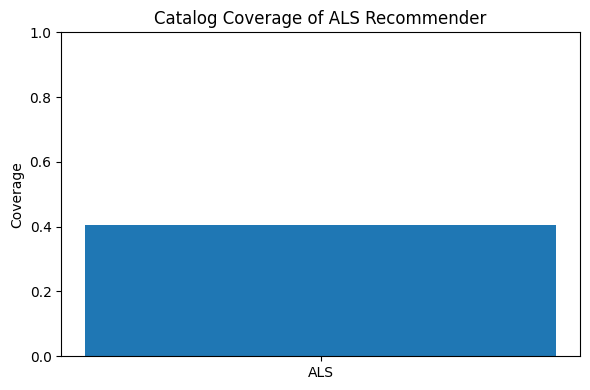

In [40]:
# graph -catalog coverage
coverage_pd = pd.DataFrame({
    "Model": ["ALS"],
    "Coverage": [coverage]
})

plt.figure(figsize=(6,4))
plt.bar(coverage_pd["Model"], coverage_pd["Coverage"])
plt.ylabel("Coverage")
plt.title("Catalog Coverage of ALS Recommender")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [41]:
#compare content-based vs als side by side
def compare_recommendations(user_id, model, ratings_df, product_tfidf_df, products_df, ratings_indexed_df, top_n=5):
    #side-by-side comparison of content-based and ALS recommendations.
    #compares top recommenndations from content-based filtering and ALS for the same user

    print(f"\n{'='*90}")
    print(f"Comparison for User {user_id}")
    print(f"{'='*90}")

    # User's top-rated products

    #show the user's own highest-rated items first for context
    #enables judgement to see if recommendations make sense
    user_top = ratings_df.filter(
        (F.col("user_id") == user_id) & (F.col("rating") >= 4.0)
    ).join(products_df, "parent_asin") \
     .select("title", "rating") \
     .orderBy(F.desc("rating")) \
     .limit(5) \
     .collect()

    print("\nUser's top-rated products:")
    for row in user_top:
        print(f" {row['rating']:.1f}  {row['title'][:70]}")

     # content-based recommendations
    #builds user profile using TF-IDF vectors of products the user rated highly
    user_profile, rated_ids = build_user_profile(user_id, ratings_df, product_tfidf_df)

    if user_profile is not None:

        #get candidate products the user hasnt already rated
        candidates = product_tfidf_df.filter(
            ~F.col("parent_asin").isin(rated_ids)
        ).collect()

        #compute cosine similarity between user profile and each candidate product vector
        cb_scores = [
            (r["parent_asin"], r["title"], cosine_similarity(user_profile, r["tfidf_features"]))
            for r in candidates
        ]
        #sort by highest simialrity score
        cb_scores.sort(key=lambda x: x[2], reverse=True)

        print(f"\nContent-Based Top {top_n}:")
        for i, (asin, title, score) in enumerate(cb_scores[:top_n], 1):
            print(f"{i}. {title[:60]:60s} | ASIN={asin} | score={score:.4f}")

    # ALS recommendations
    #convert the origioanl user_id into the indexed user_idx
    #used internally by ALS model
    user_idx_row = ratings_indexed_df.filter(
        F.col("user_id") == user_id
    ).select("user_idx").first()

    #if the user doesnt exist in the indexed dataset, ALS cannot generate recommendations

    if user_idx_row is None:
        print("\nALS Collaborative Filtering Top recommendations:")
        print("User not found in ALS indexed data.")
        return

    #extract numeric user index
    user_idx_value = int(user_idx_row["user_idx"])

    #create a small spark dataframe containing this user
    user_df = spark.createDataFrame([(user_idx_value,)], ["user_idx"])

    #ask the ALS model to recommend top N items for this user
    als_recs = model.recommendForUserSubset(user_df, top_n)

#flatten recommendation structure
    #asl returns nested arrays of recommendations so expolide to convert to rows
    als_flat = als_recs.select(
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("rec.item_idx").alias("item_idx"),
        F.col("rec.rating").alias("score")
    )

    #map internal item_inx values bacj to product ASINS
    item_lookup = ratings_indexed_df.select("item_idx", "parent_asin").dropDuplicates()

    #join with product titles for readability
    als_named = als_flat.join(item_lookup, "item_idx") \
        .join(products_df.select("parent_asin", "title"), "parent_asin") \
        .collect()

    #print als recommendations
    print(f"\nALS Collaborative Filtering Top {top_n}:")
    for i, row in enumerate(als_named[:top_n], 1):
        print(f"{i}. {row['title'][:60]:60s} | ASIN={row['parent_asin']} | score={row['score']:.4f}")

In [42]:
#show 10 unique IDs from ratings data
ratings.select("user_id").distinct().show(10, truncate=False)

#collect 3 sample users to test comparison function
sample_users = [row["user_id"] for row in ratings.select("user_id").distinct().limit(3).collect()]

#run content-based vs als comparison for each sample user
for uid in sample_users:
    compare_recommendations(uid, model, ratings, product_tfidf, products, ratings_indexed, top_n=5)

+----------------------------+
|user_id                     |
+----------------------------+
|AGKHLEW2SOWHNMFQIJGBECAF7INQ|
|AGMJ3EMDVL6OWBJF7CA5RGJLXN5A|
|AFSKPY37N3C43SOI5IEXEK5JSIYA|
|AFKNVFEXRGUGJAGMENCOWLVDYVCQ|
|AHFURURV4H35BXUUTXYMJYA36CTQ|
|AE5DIA2HDWBPNGBO2FXN2PF4NQJA|
|AF2FTNKCY6XY67BKBUO4BNJRZ4XQ|
|AHW7W34BLHHC4AYM4TPMLA2SWMMA|
|AGG3LLILZEGKCA4SAS4Q7X2Y7ISQ|
|AHATA6X6MYTC3VNBFJ3WIYVK257A|
+----------------------------+
only showing top 10 rows


Comparison for User AGKHLEW2SOWHNMFQIJGBECAF7INQ

User's top-rated products:
 5.0  herbivore natural sea mist texturizing salt spray coconut 8 oz
 4.0  natural vegan dry shampoo powder eco friendly root touch hair powder v
User AGKHLEW2SOWHNMFQIJGBECAF7INQ: profile built from 2 highly-rated products

Content-Based Top 5:
1. herbivore natural sea mist texturizing salt spray coconut tr | ASIN=B015RR870U | score=0.4718
2. moyo natural lab 8 oz spray bottle trigger sprayer empty tra | ASIN=B01DZ02WZW | score=0.4595
3. moyo natural lab 8 

Hybrid Recommender

combines content-based and ALS scores:

scorehybrid=α⋅scoreCB+(1−α)⋅scoreALS

alpha = 1.0 -> pure content based
alpha = 0.0 -> pure als

Experiments with different values of  α . questions - does the hybrid outperform either individual system?

In [43]:
def hybrid_recommend(user_id, model, ratings_df, product_tfidf_df, products_df, ratings_indexed_df, alpha=0.5, top_n=10):

    #hybrid recommender combining normalised content-based and ALS scores

    # content-based scores
    #  build the users content profile
    user_profile, rated_ids = build_user_profile(user_id, ratings_df, product_tfidf_df)

    if user_profile is None:
        print(f"Cannot build profile for user {user_id}")
        return None

    # broadcast profile for efficient distributed cosine scoring - the small user profile to all workers
    b_user_profile = sc.broadcast(user_profile)

    def get_cosine_sim(features):
        if features is None: return 0.0
        v1 = b_user_profile.value
        v2 = np.array(features)
        dot = np.dot(v1, v2)
        norm = np.linalg.norm(v1) * np.linalg.norm(v2)
        return float(dot / norm) if norm > 0 else 0.0

    cosine_udf = F.udf(get_cosine_sim, FloatType())

    # score all unrated products using content similarity
    cb_df = product_tfidf_df.filter(~F.col("parent_asin").isin(rated_ids)) \
        .withColumn("cb_score", cosine_udf(F.col("tfidf_features")))

    # Normalize content based scores to [0,1] using min/max from the cluster
    stats = cb_df.select(F.min("cb_score"), F.max("cb_score")).first()
    cb_min, cb_max = stats[0], stats[1]
    cb_range = (cb_max - cb_min) if (cb_max is not None and cb_min is not None and cb_max > cb_min) else 1.0

    cb_df = cb_df.withColumn("cb_norm", (F.col("cb_score") - cb_min) / cb_range)

    # als scores
    user_idx_row = ratings_indexed_df.filter(F.col("user_id") == user_id).select("user_idx").first()
    if not user_idx_row: return None

    user_df = spark.createDataFrame([(int(user_idx_row["user_idx"]),)], ["user_idx"])
    # gets more than top_n to ensure we have overlap for the hybrid calculation
    als_recs = model.recommendForUserSubset(user_df, 1000)

    als_flat = als_recs.select(F.explode("recommendations").alias("rec")).select(
        F.col("rec.item_idx").alias("item_idx"),
        F.col("rec.rating").alias("als_raw_score")
    )

    # map ALS indices back to ASINs
    item_lookup = ratings_indexed_df.select("item_idx", "parent_asin").distinct()
    als_df = als_flat.join(item_lookup, "item_idx")

    # normalise ALS scores
    als_stats = als_df.select(F.min("als_raw_score"), F.max("als_raw_score")).first()
    a_min, a_max = als_stats[0], als_stats[1]
    a_range = (a_max - a_min) if (a_max is not None and a_min is not None and a_max > a_min) else 1.0

    als_df = als_df.withColumn("als_norm", (F.col("als_raw_score") - a_min) / a_range)

    #combine Scores
    # join content based scores and ALS scores on parent_asin
    hybrid_df = cb_df.join(als_df.select("parent_asin", "als_norm"), "parent_asin", "outer") \
        .fillna(0, subset=["cb_norm", "als_norm"]) \
        .withColumn("hybrid_score", (F.lit(alpha) * F.col("cb_norm")) + (F.lit(1-alpha) * F.col("als_norm")))

    # final metadata join & collect
    #adds titles and returns top items
    final_recs = hybrid_df.drop("title").join(
        products_df.select("parent_asin", "title"),
        "parent_asin"
    ) \
        .orderBy(F.col("hybrid_score").desc()) \
        .select("title", "parent_asin", "hybrid_score", "cb_norm", "als_norm") \
        .limit(top_n) \
        .collect()

    # prints recommendation table
    print(f"\nHybrid Recommendations for User {user_id} (alpha={alpha}):")
    print(f"{'#':>3} {'Title':60s} {'Hybrid':>8} {'CB':>8} {'ALS':>8}")
    print("-" * 95)
    for i, row in enumerate(final_recs, 1):
        print(f"{i:3d} {str(row['title'])[:60]:60s} {row['hybrid_score']:8.4f} {row['cb_norm']:8.4f} {row['als_norm']:8.4f}")

    return final_recs

In [44]:
#tries different alpha values to see how recommendations change

for alpha in [0.0, 0.3, 0.5, 0.7, 1.0]:
   hybrid_recommend(
    sample_user,
    model,
    ratings,
    product_tfidf,
    products,
    ratings_indexed,
    alpha=alpha,
    top_n=5
)

print("\n" + "=" * 80)
print("alpha=0.0 gives pure ALS")
print("alpha=1.0 gives pure content-based")
print("Intermediate values combine both signals")

User AGKHLEW2SOWHNMFQIJGBECAF7INQ: profile built from 2 highly-rated products

Hybrid Recommendations for User AGKHLEW2SOWHNMFQIJGBECAF7INQ (alpha=0.0):
  # Title                                                          Hybrid       CB      ALS
-----------------------------------------------------------------------------------------------
  1 bestmal curly headband wig 10 inch deep wave headband wig bl   1.0000   0.6473   1.0000
  2 makeup brush cleaner kit                                       0.9608   0.1229   0.9608
  3 real african shea butter pure raw unrefined ghana ivory 8oz    0.9416   0.2669   0.9416
  4 okeps hxeredue jade roller gua sha set 2 1 rose quartz rolle   0.9260   0.4975   0.9260
  5 sweet baby shampoo 16 oz sulfate free parabens phthalates dy   0.8328   0.4479   0.8328
User AGKHLEW2SOWHNMFQIJGBECAF7INQ: profile built from 2 highly-rated products

Hybrid Recommendations for User AGKHLEW2SOWHNMFQIJGBECAF7INQ (alpha=0.3):
  # Title                                     

In [45]:
#evaluate hybrid with precision@k
def evaluate_hybrid_precision_at_k(user_ids, model, ratings_df, product_tfidf_df, products_df, ratings_indexed_df, k=10, alpha=0.5, relevance_threshold=4.0):
    #evaluates hybrid Precision@K for sample users
    #this function loops over users one at a time so ok for small evaluation sample but slow for large sample sets

    # gets all relevant items for the selected users
    # relevant items = test/user history items with high ratings
    relevant_items_df = ratings_df.filter(
        (F.col("user_id").isin(user_ids)) & (F.col("rating") >= relevance_threshold)
    ).select("user_id", "parent_asin").distinct()


    all_recs = []

    total_precision = 0.0
    valid_users = 0

    for u_id in user_ids:
        #generate top-k hybrid recomendations for this user
        # gets recommendations using the optimised distributed function
        recs = hybrid_recommend(
            u_id, model, ratings_df, product_tfidf_df,
            products_df, ratings_indexed_df, alpha, top_n=k
        )

        if not recs:
            continue

        # get relevant products for this user
        user_relevant = [
            row['parent_asin'] for row in
            relevant_items_df.filter(F.col("user_id") == u_id).collect()
        ]

        if not user_relevant:
            continue

        recommended_asins = {row['parent_asin'] for row in recs}
        hits = len(recommended_asins.intersection(set(user_relevant)))

        total_precision += (hits / k)
        valid_users += 1

    avg_precision = total_precision / valid_users if valid_users > 0 else 0.0
    print(f"\nFinal Average Precision@{k}: {avg_precision:.4f}")
    return avg_precision

In [46]:
#small sample of users for evaluation
sample_users_eval = [
    row["user_id"]
    for row in ratings.select("user_id").distinct().limit(10).collect()
]

ratings.cache()
product_tfidf.cache()
ratings_indexed.cache()

print(f"{'Alpha':>8} {'Hybrid Precision@10':>22}")
print("-" * 35)

hybrid_results = []

# run evaluation loop
for alpha in [0.0, 0.3, 0.5, 0.7, 1.0]:
    hp = evaluate_hybrid_precision_at_k(
        user_ids=sample_users_eval,
        model=model,
        ratings_df=ratings,
        product_tfidf_df=product_tfidf,
        products_df=products,
        ratings_indexed_df=ratings_indexed,
        k=10,
        alpha=alpha
    )
    hybrid_results.append((alpha, hp))
    print(f"{alpha:>8.1f} {hp:>22.4f}")

   Alpha    Hybrid Precision@10
-----------------------------------
User AGKHLEW2SOWHNMFQIJGBECAF7INQ: profile built from 2 highly-rated products

Hybrid Recommendations for User AGKHLEW2SOWHNMFQIJGBECAF7INQ (alpha=0.0):
  # Title                                                          Hybrid       CB      ALS
-----------------------------------------------------------------------------------------------
  1 bestmal curly headband wig 10 inch deep wave headband wig bl   1.0000   0.6473   1.0000
  2 makeup brush cleaner kit                                       0.9608   0.1229   0.9608
  3 real african shea butter pure raw unrefined ghana ivory 8oz    0.9416   0.2669   0.9416
  4 okeps hxeredue jade roller gua sha set 2 1 rose quartz rolle   0.9260   0.4975   0.9260
  5 sweet baby shampoo 16 oz sulfate free parabens phthalates dy   0.8328   0.4479   0.8328
  6 salon grafix professional spray liquid gel mega hold unscent   0.7949   0.1931   0.7949
  7 tinksky 12pcs waterproof flamingo t

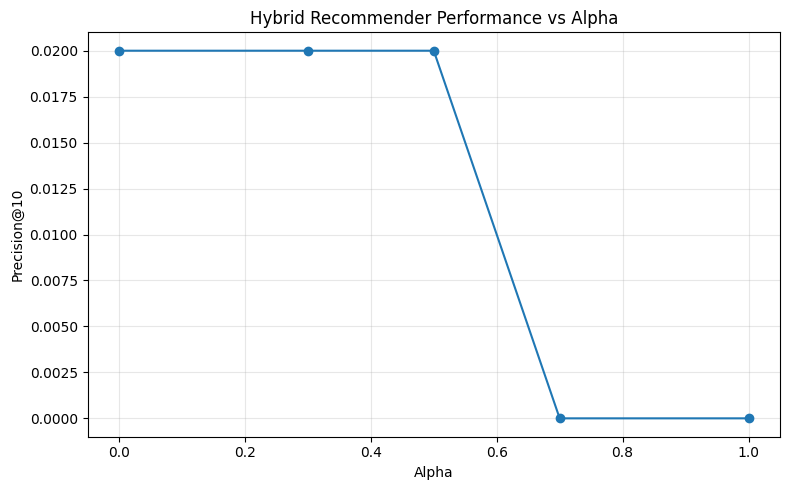

In [47]:
# graph - hybrid precision vs alpha
hybrid_pd = pd.DataFrame(hybrid_results, columns=["Alpha", "Precision@10"])

plt.figure(figsize=(8,5))
plt.plot(hybrid_pd["Alpha"], hybrid_pd["Precision@10"], marker="o")
plt.xlabel("Alpha")
plt.ylabel("Precision@10")
plt.title("Hybrid Recommender Performance vs Alpha")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Popularity Precision@10: 0.0000
User AGKHLEW2SOWHNMFQIJGBECAF7INQ: profile built from 2 highly-rated products
User AGMJ3EMDVL6OWBJF7CA5RGJLXN5A: profile built from 1 highly-rated products
User AFSKPY37N3C43SOI5IEXEK5JSIYA: profile built from 11 highly-rated products
User AFKNVFEXRGUGJAGMENCOWLVDYVCQ: profile built from 2 highly-rated products
User AHFURURV4H35BXUUTXYMJYA36CTQ: profile built from 1 highly-rated products
User AE5DIA2HDWBPNGBO2FXN2PF4NQJA: profile built from 1 highly-rated products
User AF2FTNKCY6XY67BKBUO4BNJRZ4XQ: profile built from 1 highly-rated products
User AHW7W34BLHHC4AYM4TPMLA2SWMMA: profile built from 1 highly-rated products
User AGG3LLILZEGKCA4SAS4Q7X2Y7ISQ: profile built from 2 highly-rated products
User AHATA6X6MYTC3VNBFJ3WIYVK257A: profile built from 4 highly-rated products

Content-Based Precision@10: 0.0000
ALS Precision@10: 0.00114031399653392
Best Hybrid Alpha: 0.0
Hybrid Precision@10: 0.02
           Model  Precision@10
0     Popularity       0.00000
1

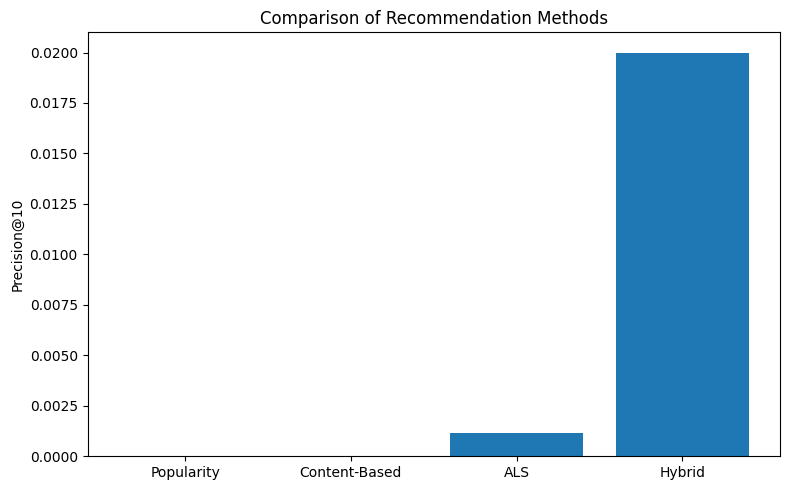

In [48]:
# final comparison across all 4 methods

eval_users = [row["user_id"] for row in ratings.select("user_id").distinct().limit(10).collect()]

popularity_p10 = evaluate_popularity_precision_at_k(
    ratings_df=ratings,
    popularity_df=popular_products,
    k=10,
    relevance_threshold=4.0,
    sample_n_users=10
)

content_p10 = evaluate_content_precision_at_k(
    user_ids=eval_users,
    ratings_df=ratings,
    product_tfidf_df=product_tfidf,
    products_df=products,
    k=10,
    relevance_threshold=4.0
)

als_p10 = [p for k, p in precisions if k == 10][0]
print("ALS Precision@10:", als_p10)

best_alpha, hybrid_p10 = max(hybrid_results, key=lambda x: x[1])
print("Best Hybrid Alpha:", best_alpha)
print("Hybrid Precision@10:", hybrid_p10)

comparison_pd = pd.DataFrame({
    "Model": ["Popularity", "Content-Based", "ALS", "Hybrid"],
    "Precision@10": [popularity_p10, content_p10, als_p10, hybrid_p10]
})

print(comparison_pd)

plt.figure(figsize=(8,5))
plt.bar(comparison_pd["Model"], comparison_pd["Precision@10"])
plt.ylabel("Precision@10")
plt.title("Comparison of Recommendation Methods")
plt.tight_layout()
plt.show()

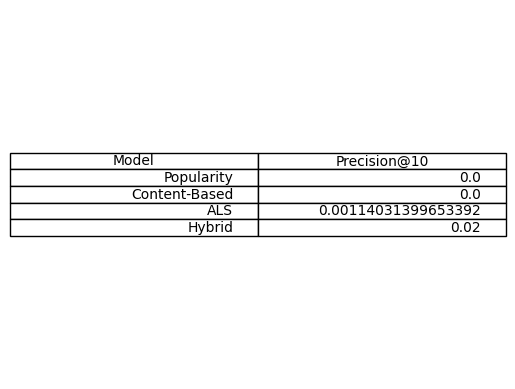

In [49]:
# save results table as an image for the report
fig, ax = plt.subplots()

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=comparison_pd.values,
    colLabels=comparison_pd.columns,
    loc='center'
)

plt.savefig("final_results_table.png", bbox_inches='tight')
plt.show()

In [50]:
# clean - stop spark session
#spark.stop()